# **Q-Q Plot (Quantile-Quantile Plot)**

O Q-Q Plot (Quantile-Quantile Plot) é uma ferramenta gráfica diagnóstica usada para verificar se um conjunto de dados segue uma determinada distribuição teórica — **mais comummente, a distribuição normal (Gaussiana)**.

Na biblioteca **scipy.stats**, o gráfico é gerado pela função **stats.probplot()** em conjunto com a matplotlib.


## **Como Funciona a Construção do Gráfico**

**O Q-Q Plot** compara os quantis dos seus dados reais com os quantis teóricos esperados de uma distribuição normal perfeita:

* **Eixo X (Theoretical Quantiles):** Representa onde os pontos deveriam estar localizados se a amostra viesse de uma distribuição normal padrão ($\mu=0, \sigma=1$).

* **Eixo Y (Sample Quantiles / Ordered Values)**: Contém os valores reais do seu conjunto de dados, ordenados do menor para o maior.Linha de Referência

* **(Linha Vermelha):** Uma linha de regressão que passa pelos quantis teóricos. Se plot=plt for fornecido, a scipy.stats.probplot desenha essa linha vermelha para servir de guia visual.




## **Como Interpretar o Gráfico**
* **Dados Normais**: Se a sua amostra segue uma distribuição normal, os pontos azuis caem exatamente em cima ou muito próximos da linha reta vermelha.

* **Desvios da Normalidade:** O formato em que os pontos se afastam da linha reta revela o tipo de deformação presente nos dados:

## **Exemplo 1 - Grafico QQ plot**

Vamos criar uma série temporal com valores **normalmente distribuidos** com **média zero** e **variância 1**. A série se inicia no ano de **1985** e termina no ano de **2025**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from  matplotlib.pylab import rcParams
#rcParams['figure.figsize'] =15,7

In [ ]:
  # reprodução dos resultados.
np.random.seed(44)

In [ ]:
# Os dados terão distribuição normal com média zero e variancia 1.

dados_v0 =np.random.normal(0,1,41)

In [ ]:
dados_v1 = pd.DataFrame(dados_v0,columns=['valores'])

In [ ]:
indice = pd.date_range('1985', periods=len(dados_v0),freq='YE')

In [ ]:
serie_v1= pd.Series(dados_v1['valores'].values, index=indice)

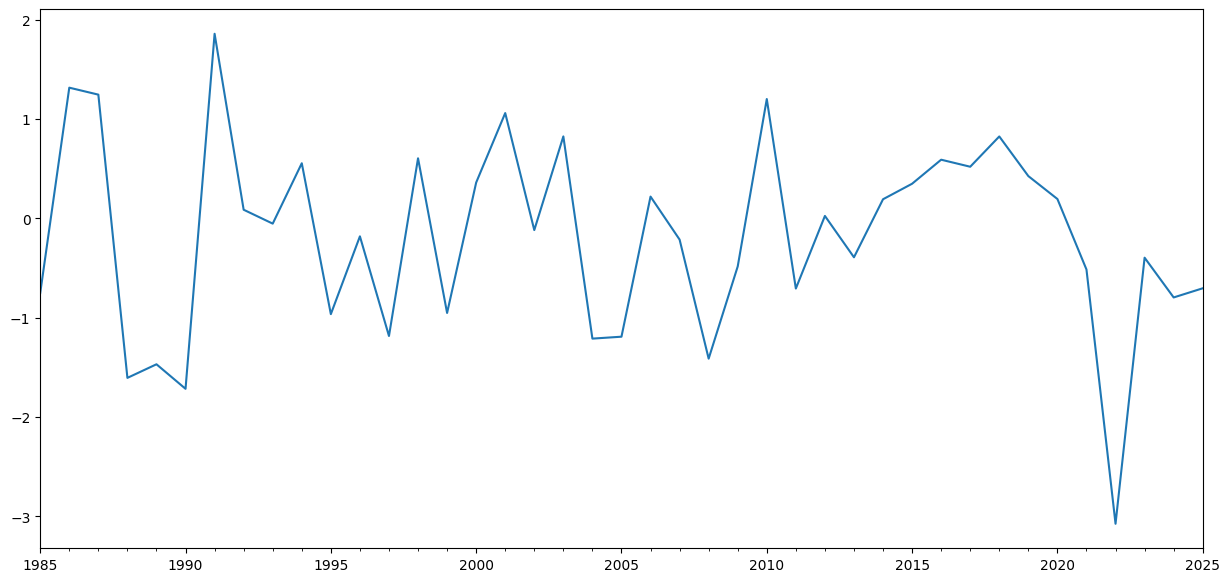

In [ ]:
serie_v1.plot()
plt.show()

In [ ]:
import scipy.stats as stats

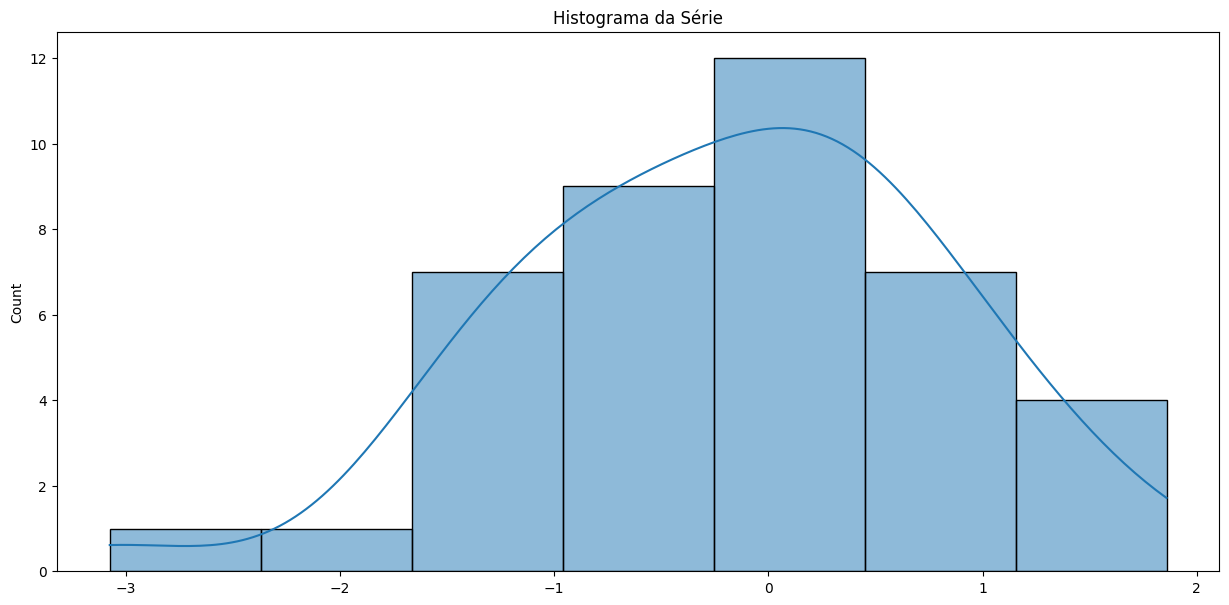

In [ ]:
import seaborn as sns
sns.histplot(serie_v1, kde=True)
plt.title('Histograma da Série')
plt.show()


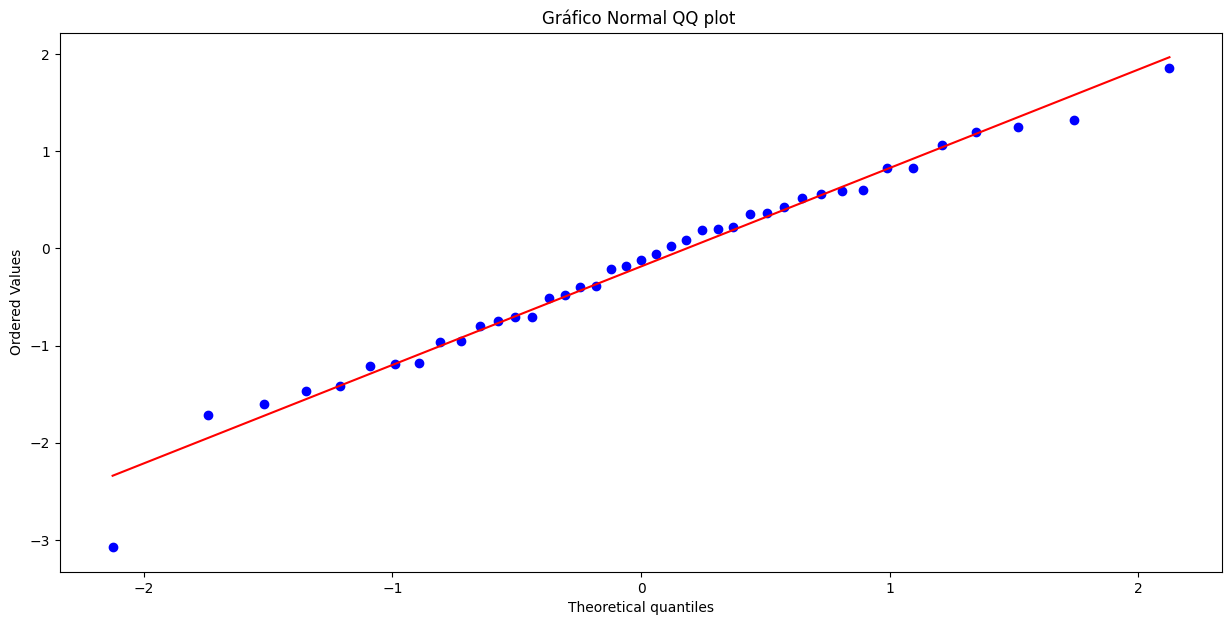

In [ ]:
stats.probplot(serie_v1,dist='norm',plot=plt)
plt.title("Gráfico Normal QQ plot ")
plt.show()

# **Teste de Shapiro-Wilk**


O **Teste de Shapiro-Wilk** é um dos testes estatísticos mais potentes para verificar se uma amostra de dados provém de uma distribuição normal (Gaussiana). É amplamente utilizado para validar os pressupostos de testes paramétricos (como o Teste t de Student ou ANOVA) e modelos de regressão.

## **Como Funciona**
O teste avalia a hipótese nula de que a sua amostra segue uma distribuição normal:
* **Hipótese Nula ($H_0$):** Os dados seguem uma distribuição normal.
* **Hipótese  Alternativa ($H_1$)**: Os dados não seguem uma distribuição normal.

## **Como Interpretar os Resultados ($p\text{-value}$)**
 A decisão é tomada com base no nível de significância ($\alpha$), tradicionalmente fixado em $0,05$ (5%):
* $p\text{-value} > 0,05$: Não há evidências estatísticas para rejeitar a hipótese nula ($H_0$). Conclusão: Assume-se que os dados seguem uma distribuição normal.
* $p\text{-value} \le 0,05$: Rejeita-se  a hipótese nula ($H_0$). Conclusão: Os dados não seguem uma distribuição normal.

In [ ]:
estatistica, p_value = stats.shapiro(serie_v1)

print(f"Estatística W: {estatistica:.4f}")
print(f"p-value: {p_value:.4f}")

# 3. Interpretação automática
alpha = 0.05
if p_value > alpha:
    print("Os dados parecem seguir uma distribuição normal (Falha em rejeitar H0)")
else:
    print("Os dados NÃO seguem uma distribuição normal (Rejeita H0)")

Estatística W: 0.9836
p-value: 0.8087
Os dados parecem seguir uma distribuição normal (Falha em rejeitar H0)
